C'est un premier essai 

## Imports

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("GPU disponible:", torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilisé: {device}")

PyTorch version: 2.11.0+cpu
GPU disponible: False
Device utilisé: cpu


## Créer des données synthétiques

On va créer des **données factices** :
- 200 échantillons
- 2 voies (canaux)
- 100 points temporels chacun
- 2 classes à prédire (0 ou 1)

In [2]:
# Paramètres
n_samples = 200       # Nombre d'échantillons
n_channels = 2        # Nombre de voies (voieBasse, voieHaute)
time_steps = 100      # Longueur de chaque série temporelle
n_classes = 2         # Classes à prédire: 0 ou 1

# Créer des données aléatoires
np.random.seed(42)
X = np.random.randn(n_samples, n_channels, time_steps).astype(np.float32)
y = np.random.randint(0, n_classes, n_samples)

# Normaliser
X = (X - X.mean(axis=2, keepdims=True)) / (X.std(axis=2, keepdims=True) + 1e-7)

# Afficher les shapes
print(f"X shape: {X.shape}  (échantillons, voies, temps)")
print(f"y shape: {y.shape}  (classes: {np.unique(y)})")

# Diviser en train/test
split = int(0.8 * n_samples)
X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]

print(f"\nTrain: {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

# Convertir en tenseurs PyTorch
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

# Créer les DataLoaders
batch_size = 16
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nDataLoaders créés avec batch_size={batch_size}")

X shape: (200, 2, 100)  (échantillons, voies, temps)
y shape: (200,)  (classes: [0 1])

Train: 160 samples
Test: 40 samples

DataLoaders créés avec batch_size=16


## 3️ Construire un modèle CNN 1D simple

Architecture super simple :
- **Input**: (batch, 2 voies, 100 temps)
- **Conv1D**: 2 canaux → 16 filtres (kernel=3)
- **MaxPool1D**: Réduit la taille
- **Flatten**: Convertit en vecteur
- **Dense 1**: 64 neurones
- **Dense 2**: 2 classes (output)

In [3]:
class SimpleCNN1D(nn.Module):
    def __init__(self, num_channels, num_classes):
        super(SimpleCNN1D, self).__init__()
        
        # Couche convolutive 1D
        # in_channels=2 (voieBasse, voieHaute)
        # out_channels=16 (16 filtres extraits)
        # kernel_size=3 (regarde 3 points à la fois)
        self.conv1 = nn.Conv1d(in_channels=num_channels, out_channels=16, kernel_size=3, padding=1)
        
        # Max pooling : réduit les dimensions par 2
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        
        # ReLU : fonction d'activation (ajoute de la non-linéarité)
        self.relu = nn.ReLU()
        
        # Après conv1d (100 → 100) et pool (100 → 50)
        # Size = 16 * 50 = 800
        self.fc1 = nn.Linear(16 * 50, 64)
        self.fc2 = nn.Linear(64, num_classes)
        
        self.dropout = nn.Dropout(0.2)
    
    def forward(self, x):
        """Passage avant (forward pass) du réseau"""
        print(f"  Input shape: {x.shape}")
        
        # Conv + ReLU + Pool
        x = self.conv1(x)
        print(f"  Après conv1d: {x.shape}")
        
        x = self.relu(x)
        x = self.pool(x)
        print(f"  Après pool: {x.shape}")
        
        # Aplatir (flatten)
        x = x.view(x.size(0), -1)
        print(f"  Après flatten: {x.shape}")
        
        # Fully connected
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

# Créer le modèle
model = SimpleCNN1D(num_channels=n_channels, num_classes=n_classes).to(device)

print("Modèle créé ✓")
print(f"\nNombre de paramètres: {sum(p.numel() for p in model.parameters()):,}")

# Tester avec un batch
print("\n--- Test du forward pass ---")
dummy_batch = X_train[:2].to(device)  # 2 échantillons
with torch.no_grad():
    output = model(dummy_batch)
    print(f"Output shape: {output.shape}")

Modèle créé ✓

Nombre de paramètres: 51,506

--- Test du forward pass ---
  Input shape: torch.Size([2, 2, 100])
  Après conv1d: torch.Size([2, 16, 100])
  Après pool: torch.Size([2, 16, 50])
  Après flatten: torch.Size([2, 800])
Output shape: torch.Size([2, 2])


## 4️ Entraîner le modèle

**Boucle d'entraînement** :
1. Forward pass : données → réseau → prédictions
2. Calculer la loss (erreur)
3. Backward pass : calculer les gradients
4. Optimizer step : ajuster les poids

In [4]:
# Setup de l'entraînement
learning_rate = 0.001
num_epochs = 20
criterion = nn.CrossEntropyLoss()  # Perte pour classification
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Listes pour tracker l'apprentissage
losses = []

print("Début de l'entraînement...\n")

# Boucle d'entraînement
for epoch in range(num_epochs):
    model.train()  # Mode entraînement
    epoch_loss = 0.0
    
    # Itérer sur les batches
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        # ===== FORWARD PASS =====
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        
        # ===== BACKWARD PASS =====
        optimizer.zero_grad()  # Vider les gradients précédents
        loss.backward()         # Calculer les gradients (backpropagation)
        optimizer.step()        # Mettre à jour les poids
        
        epoch_loss += loss.item()
    
    # Moyenne de la loss sur tous les batches
    epoch_loss /= len(train_loader)
    losses.append(epoch_loss)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:2d}/{num_epochs} - Loss: {epoch_loss:.4f}")

print("\n✓ Entraînement terminé!")

Début de l'entraînement...

  Input shape: torch.Size([16, 2, 100])
  Après conv1d: torch.Size([16, 16, 100])
  Après pool: torch.Size([16, 16, 50])
  Après flatten: torch.Size([16, 800])
  Input shape: torch.Size([16, 2, 100])
  Après conv1d: torch.Size([16, 16, 100])
  Après pool: torch.Size([16, 16, 50])
  Après flatten: torch.Size([16, 800])
  Input shape: torch.Size([16, 2, 100])
  Après conv1d: torch.Size([16, 16, 100])
  Après pool: torch.Size([16, 16, 50])
  Après flatten: torch.Size([16, 800])
  Input shape: torch.Size([16, 2, 100])
  Après conv1d: torch.Size([16, 16, 100])
  Après pool: torch.Size([16, 16, 50])
  Après flatten: torch.Size([16, 800])
  Input shape: torch.Size([16, 2, 100])
  Après conv1d: torch.Size([16, 16, 100])
  Après pool: torch.Size([16, 16, 50])
  Après flatten: torch.Size([16, 800])
  Input shape: torch.Size([16, 2, 100])
  Après conv1d: torch.Size([16, 16, 100])
  Après pool: torch.Size([16, 16, 50])
  Après flatten: torch.Size([16, 800])
  Input shap

## 5️ Évaluation et visualisation

  Input shape: torch.Size([16, 2, 100])
  Après conv1d: torch.Size([16, 16, 100])
  Après pool: torch.Size([16, 16, 50])
  Après flatten: torch.Size([16, 800])
  Input shape: torch.Size([16, 2, 100])
  Après conv1d: torch.Size([16, 16, 100])
  Après pool: torch.Size([16, 16, 50])
  Après flatten: torch.Size([16, 800])
  Input shape: torch.Size([8, 2, 100])
  Après conv1d: torch.Size([8, 16, 100])
  Après pool: torch.Size([8, 16, 50])
  Après flatten: torch.Size([8, 800])
Accuracy sur test: 40.00%


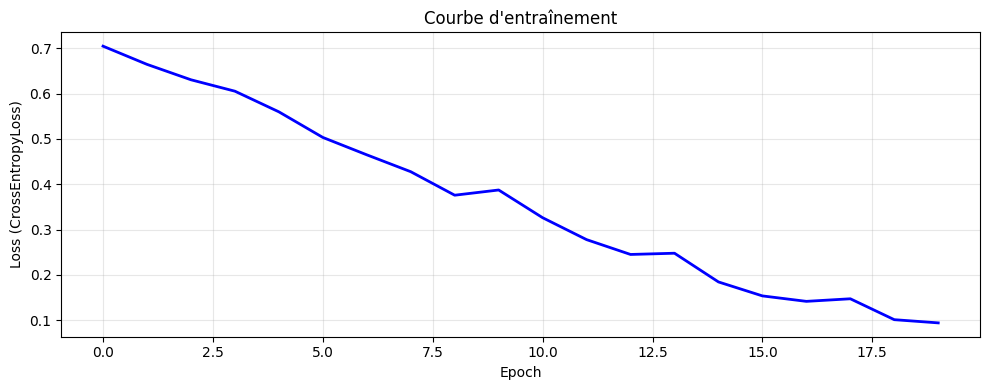

In [5]:
# Évaluer sur les données de test
model.eval()  # Mode évaluation
correct = 0
total = 0

with torch.no_grad():  # Pas besoin de calculer les gradients en test
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        outputs = model(batch_x)
        _, predicted = torch.max(outputs.data, 1)  # Classe prédite
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

accuracy = correct / total
print(f"Accuracy sur test: {accuracy*100:.2f}%")

# Visualiser la courbe de loss
plt.figure(figsize=(10, 4))
plt.plot(losses, linewidth=2, color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss (CrossEntropyLoss)')
plt.title('Courbe d\'entraînement')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Prédiction sur un seul exemple

  Input shape: torch.Size([1, 2, 100])
  Après conv1d: torch.Size([1, 16, 100])
  Après pool: torch.Size([1, 16, 50])
  Après flatten: torch.Size([1, 800])
Prédiction: Classe 0
Vrai label: Classe 1
Confiance: 95.65%
Probabilités: Classe 0=0.9565, Classe 1=0.0435


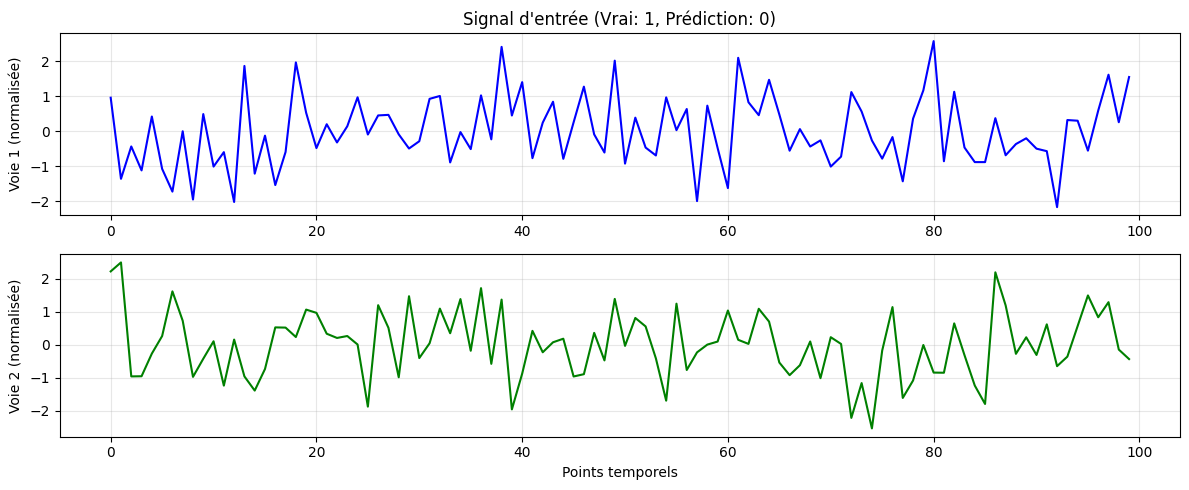

In [6]:
# Prendre le premier échantillon de test
idx = 0
sample = X_test[idx].unsqueeze(0).to(device)  # Ajouter la dimension batch
true_label = y_test[idx].item()

# Faire une prédiction
model.eval()
with torch.no_grad():
    output = model(sample)
    probs = torch.softmax(output, dim=1)
    prediction = torch.argmax(output, dim=1).item()

print(f"Prédiction: Classe {prediction}")
print(f"Vrai label: Classe {true_label}")
print(f"Confiance: {probs[0, prediction]*100:.2f}%")
print(f"Probabilités: Classe 0={probs[0, 0]:.4f}, Classe 1={probs[0, 1]:.4f}")

# Visualiser le signal d'entrée
fig, axes = plt.subplots(2, 1, figsize=(12, 5))

# Voie 1
axes[0].plot(X_test[idx, 0, :].cpu().numpy(), linewidth=1.5, color='blue')
axes[0].set_ylabel('Voie 1 (normalisée)')
axes[0].set_title(f'Signal d\'entrée (Vrai: {true_label}, Prédiction: {prediction})')
axes[0].grid(True, alpha=0.3)

# Voie 2
axes[1].plot(X_test[idx, 1, :].cpu().numpy(), linewidth=1.5, color='green')
axes[1].set_ylabel('Voie 2 (normalisée)')
axes[1].set_xlabel('Points temporels')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##  résumés

### **Tensors**
- PyTorch utilise des **tensors** (comme les arrays NumPy)
- Peuvent être sur CPU ou GPU
- Exemple: `(batch_size=16, channels=2, time_steps=100)`

### **Forward Pass**
```python
outputs = model(batch_x)  # Données passent dans le réseau
```
- Input → Conv1D → ReLU → MaxPool → Flatten → FC → Output

### **Loss (Perte)**
```python
loss = criterion(outputs, batch_y)  # Compare prédictions vs vraies labels
```
- CrossEntropyLoss pour classification
- MSELoss pour régression

### **Backward Pass (Backpropagation)**
```python
loss.backward()  # Calcule les gradients ∇Loss pour tous les poids
```
- Utilise la chaîne de dérivation (chain rule)
- Répond à la question: "Comment modifier les poids pour réduire la loss?"

### **Optimizer.step()**
```python
optimizer.step()  # Ajuste les poids: w = w - lr * gradient
```
- Adam, SGD, etc. définissent comment ajuster les poids

### **Validation**
```python
model.eval()          # Mode évaluation (désactive dropout, batch norm)
with torch.no_grad(): # Pas besoin de calculer les gradients
    output = model(x)
```

---

